In [1]:
import pandas as pd

data = pd.read_csv('data/smart_speaker_data.csv')
data.tail()

,功能,使用次数,平均响应时间(秒)
3,播放音乐,870,2.5
4,控制家居,620,3.8
5,提醒事项,580,1.5
6,查询知识,520,2.0
7,设置闹钟,480,1.3


In [2]:
len(data)

8

<Figure size 1000x600 with 0 Axes>

C:\Users\qgao2\AppData\Local\Temp\ipykernel_49096\1890340519.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='功能',y='使用次数',data=data,palette='viridis')


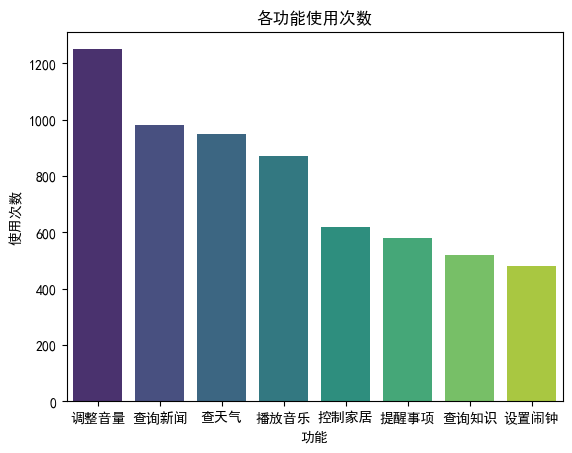

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.show()

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns

sns.barplot(x='功能',y='使用次数',data=data,palette='viridis')
plt.title('各功能使用次数')
# plt.show()
plt.savefig('function_usedtimes.png')

In [12]:
most_used = data.loc[data['使用次数'].idxmax()]['功能']
least_used = data.loc[data['使用次数'].idxmin()]['功能']

print(f"{most_used},{least_used}")

调整音量,设置闹钟


In [13]:
print(data.loc[data['使用次数'].idxmax()])

功能           调整音量
使用次数         1250
平均响应时间(秒)     0.8
Name: 0, dtype: object


In [14]:
print(data['使用次数'].idxmax())

0


In [16]:
print(data['功能'])

0    调整音量
1    查询新闻
2     查天气
3    播放音乐
4    控制家居
5    提醒事项
6    查询知识
7    设置闹钟
Name: 功能, dtype: object


C:\Users\qgao2\AppData\Local\Temp\ipykernel_49096\2788775627.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='平均响应时间(秒)', y='功能', data=data, palette='coolwarm')


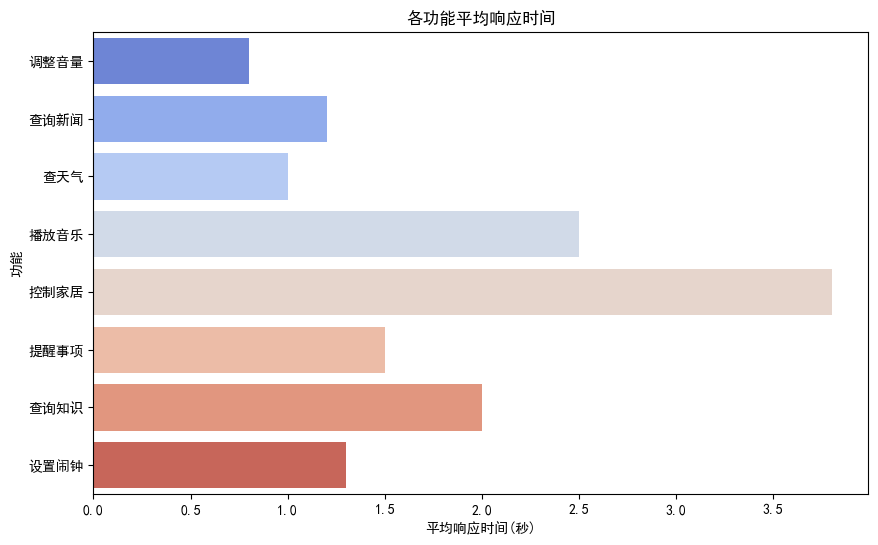

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='平均响应时间(秒)', y='功能', data=data, palette='coolwarm')
plt.title('各功能平均响应时间')
# plt.show()#不要调用，否则保存图片为空白
plt.savefig('function_rt.png')

In [18]:
print(data['平均响应时间(秒)'] > 3)

0    False
1    False
2    False
3    False
4     True
5    False
6    False
7    False
Name: 平均响应时间(秒), dtype: bool


In [19]:
data[data['平均响应时间(秒)'] > 3]

,功能,使用次数,平均响应时间(秒)
4,控制家居,620,3.8


In [20]:
long_response = data[data['平均响应时间(秒)'] > 3]['功能'].tolist()
medium_response = data[(data['平均响应时间(秒)'] >= 1.5) & (data['平均响应时间(秒)'] <= 3)]['功能'].tolist()
short_response = data[data['平均响应时间(秒)'] < 1.5]['功能'].tolist()

print(f"响应时间较长的功能: {', '.join(long_response)}")
print(f"响应时间适中的功能: {', '.join(medium_response)}")
print(f"响应时间较短的功能: {', '.join(short_response)}")

响应时间较长的功能: 控制家居
响应时间适中的功能: 播放音乐, 提醒事项, 查询知识
响应时间较短的功能: 调整音量, 查询新闻, 查天气, 设置闹钟


# 优化建议
根据以上分析，我们可以提出以下优化方向：
- 网络连接与设备交互优化：针对控制家居功能响应时间较长的问题，可以强化网络连接稳定性，采用更高效的通信协议。
- 提升信息检索效率：对于查询知识功能，可以优化检索算法，加快数据处理速度。
- 增强本地处理能力：对于播放音乐和查天气等功能，可以增加本地缓存和预加载机制，减少对外部资源的依赖。

In [32]:
from docx import Document

doc = Document()
advice = '''
# 优化建议
根据以上分析，我们可以提出以下优化方向：

网络连接与设备交互优化：针对控制家居功能响应时间较长的问题，可以强化网络连接稳定性，采用更高效的通信协议。
提升信息检索效率：对于查询知识功能，可以优化检索算法，加快数据处理速度。
增强本地处理能力：对于播放音乐和查天气等功能，可以增加本地缓存和预加载机制，减少对外部资源的依赖。
'''
from docx.shared import Inches
# 插入第一张图片
try:
    doc.add_picture('function_usedtimes.png', width=Inches(6))
except Exception as e:
    print(f"插入图片 'function_usedtimes.png' 时出错: {e}")

# 插入第二张图片
try:
    doc.add_picture('function_rt.png', width=Inches(6))
except Exception as e:
    print(f"插入图片 'function_rt.png' 时出错: {e}")
doc.add_paragraph(advice)
doc.save('result.docx');